In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import skimage as ski
import imageio
from monai.transforms import GridSplit
#from bioio.writers import OmeTiffWriter
from bioio import BioImage

sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses')

/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load ome tiff images

5 channels:
1. CDH5+Tubulin
2. Mean of BF
3. MIP of BF
4. STD of BF
5. BF center slice

In [3]:
path_to_imgs = "/allen/aics/assay-dev/computational/data/holistic/endos/feasibility/tiff_temp_folder"
os.listdir(path_to_imgs)

['20240305_T01_001.ome.zarr',
 '20240305_T01_001_TP00000.ome.tif',
 '20240305_T01_001_TP00001.ome.tif',
 '20240305_T01_001_TP00002.ome.tif',
 '20240305_T01_001_TP00003.ome.tif',
 '20240305_T01_001_TP00004.ome.tif',
 '20240305_T01_001_TP00005.ome.tif',
 '20240305_T01_001_TP00006.ome.tif',
 '20240305_T01_001_TP00007.ome.tif',
 '20240305_T01_001_TP00008.ome.tif',
 '20240305_T01_001_TP00009.ome.tif',
 '20240305_T01_001_TP00010.ome.tif',
 '20240305_T01_001_TP00011.ome.tif',
 '20240305_T01_001_TP00012.ome.tif',
 '20240305_T01_001_TP00013.ome.tif',
 '20240305_T01_001_TP00014.ome.tif',
 '20240305_T01_001_TP00015.ome.tif',
 '20240305_T01_001_TP00016.ome.tif',
 '20240305_T01_001_TP00017.ome.tif',
 '20240305_T01_001_TP00018.ome.tif',
 '20240305_T01_001_TP00019.ome.tif',
 '20240305_T01_001_TP00020.ome.tif',
 '20240305_T01_001_TP00021.ome.tif',
 '20240305_T01_001_TP00022.ome.tif',
 '20240305_T01_001_TP00023.ome.tif',
 '20240305_T01_001_TP00024.ome.tif',
 '20240305_T01_001_TP00025.ome.tif',
 '202403

In [4]:
img_tif = imageio.imread(path_to_imgs+'/20240305_T01_001_TP00000.ome.tif')

/tmp/ipykernel_8345/2996249275.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img_tif = imageio.imread(path_to_imgs+'/20240305_T01_001_TP00000.ome.tif')


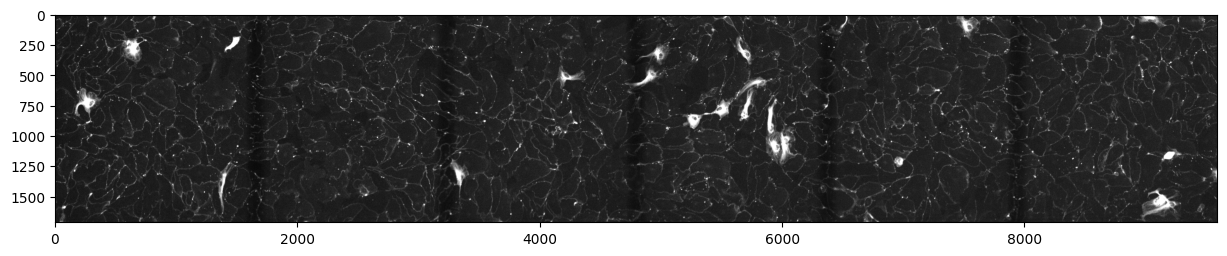

In [5]:
fig = plt.figure(figsize=(15,20))
vmin, vmax = np.percentile(img_tif[0], q=(0.5, 99.5))
cdh5_corrected = ski.exposure.rescale_intensity(img_tif[0], in_range=(vmin, vmax),out_range='uint8') # adjust contrast for visualization
plt.imshow(cdh5_corrected,cmap='gray')

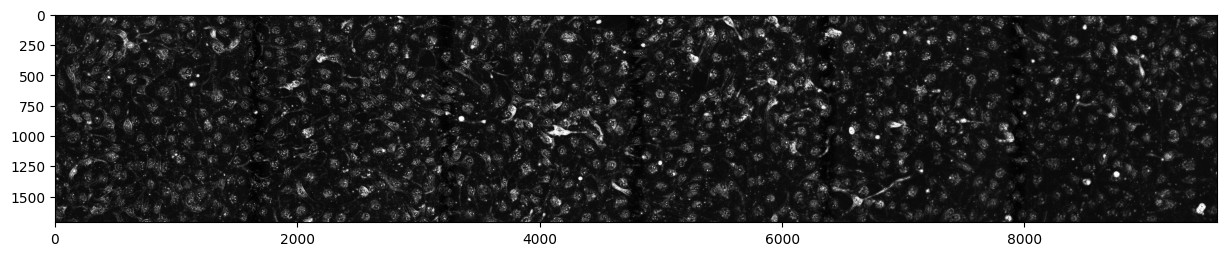

In [6]:
fig = plt.figure(figsize=(15,20))
vmin, vmax = np.percentile(img_tif[3], q=(0.5, 99.5))
bf_corrected = ski.exposure.rescale_intensity(img_tif[3], in_range=(vmin, vmax),out_range='uint8') # adjust contrast for visualization
plt.imshow(bf_corrected,cmap='gray')

## Load CDH5 MAE data

Masked autoencoder dataset info:
- columns 0-255 are the latent features of the contrastive model
- location gives a unique id for each 512x512 patch of the image (stitched FOVs) that is consistent across time (54 locations)
- time is the index into the movie (0 to 576, units 5 minutes)

Original endothelial cell dataset info (from `cellsmap/cellsmap/data_config.yaml`):
- flow rate of 20 dyn/cm^2 from 0 to 24 hours
- flow rate of 6 dyn/cm^2 from 24 to 48 hours
- time interval between images (data points) is 5 minutes

Data loaded and preprocessed in `utils/mae_feats_init.py`.

In [10]:
exp_var = np.load('data/MAE_ExpVar.npy')
pcs = np.load('data/MAE_PCs.npy')

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Number of modes to explain 95% of variance:  12


In [11]:
X_t = np.load('data/MAE_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array

X_t_high = np.load('data/MAE_95pctVarPCs_highFlow.npy')
X_t_low = np.load('data/MAE_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

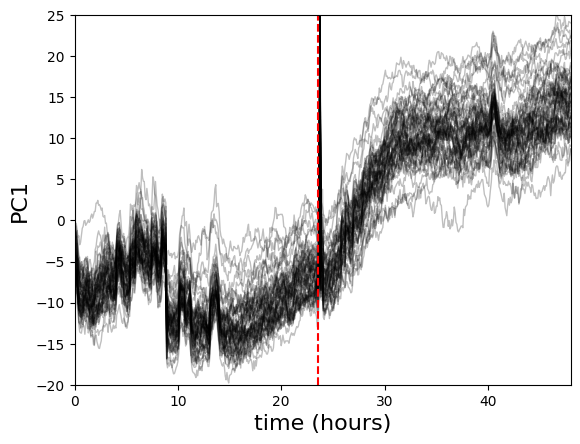

In [12]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-20,25])
plt.vlines(5*t_change/60,-20,25,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

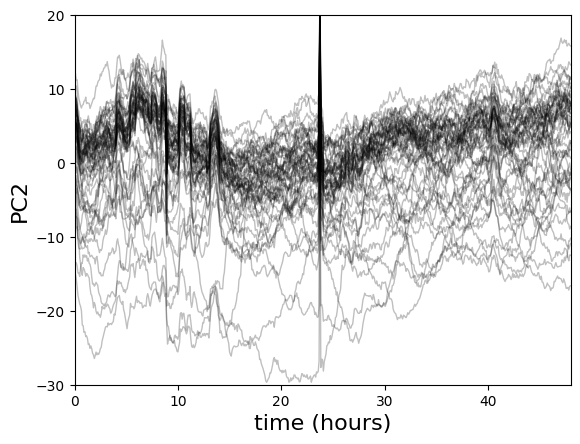

In [13]:
# plot 2nd PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-30,20])
#plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC2", fontsize=16)

### Find trajectories that have different PC2 dynamics

In [14]:
hightraj = np.where(X_t[:,0,1] > 0)[0]

In [15]:
lowtraj = np.where(X_t[:,0,1] < -5)[0]

In [16]:
np.argmin(X_t[:,200,1])

11

Text(0, 0.5, 'PC2')

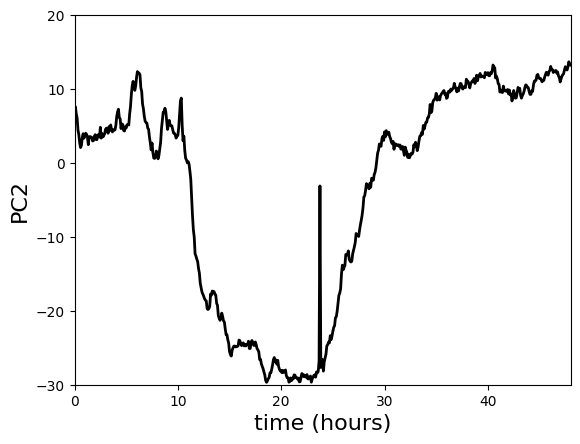

In [17]:
# plot 2nd PCA mode vs time for each location at high flow
for i in [11]:
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,1],'k-',alpha=1.0,linewidth=2)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-30,20])
#plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC2", fontsize=16)

In [19]:
path_to_crops = '//allen/aics/assay-dev/users/Benji/cellsmap/results/patches'
os.listdir(path_to_crops)

['T=0_patch=0.tiff',
 'T=0_patch=1.tiff',
 'T=0_patch=10.tiff',
 'T=0_patch=11.tiff',
 'T=0_patch=12.tiff',
 'T=0_patch=13.tiff',
 'T=0_patch=14.tiff',
 'T=0_patch=15.tiff',
 'T=0_patch=16.tiff',
 'T=0_patch=17.tiff',
 'T=0_patch=18.tiff',
 'T=0_patch=19.tiff',
 'T=0_patch=2.tiff',
 'T=0_patch=20.tiff',
 'T=0_patch=21.tiff',
 'T=0_patch=22.tiff',
 'T=0_patch=23.tiff',
 'T=0_patch=24.tiff',
 'T=0_patch=25.tiff',
 'T=0_patch=26.tiff',
 'T=0_patch=27.tiff',
 'T=0_patch=28.tiff',
 'T=0_patch=29.tiff',
 'T=0_patch=3.tiff',
 'T=0_patch=30.tiff',
 'T=0_patch=31.tiff',
 'T=0_patch=32.tiff',
 'T=0_patch=33.tiff',
 'T=0_patch=34.tiff',
 'T=0_patch=35.tiff',
 'T=0_patch=36.tiff',
 'T=0_patch=37.tiff',
 'T=0_patch=38.tiff',
 'T=0_patch=39.tiff',
 'T=0_patch=4.tiff',
 'T=0_patch=40.tiff',
 'T=0_patch=41.tiff',
 'T=0_patch=42.tiff',
 'T=0_patch=43.tiff',
 'T=0_patch=44.tiff',
 'T=0_patch=45.tiff',
 'T=0_patch=46.tiff',
 'T=0_patch=47.tiff',
 'T=0_patch=48.tiff',
 'T=0_patch=49.tiff',
 'T=0_patch=5.t

/tmp/ipykernel_32235/2568137642.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img= imageio.imread(path_to_crops+'/T=0_patch='+str(11)+'.tiff')


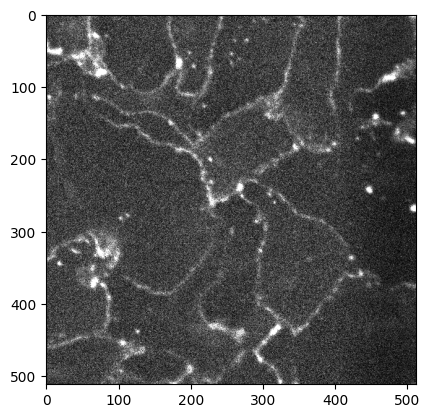

In [20]:
img= imageio.imread(path_to_crops+'/T=0_patch='+str(11)+'.tiff')
vmin, vmax = np.percentile(img, q=(0.5, 99.5))
img_corrected = ski.exposure.rescale_intensity(img, in_range=(vmin, vmax),out_range='uint8') # adjust contrast for visualization
plt.imshow(img_corrected,cmap='gray')

/tmp/ipykernel_32235/1012187965.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img= imageio.imread(path_to_crops+'/T=200_patch='+str(11)+'.tiff')


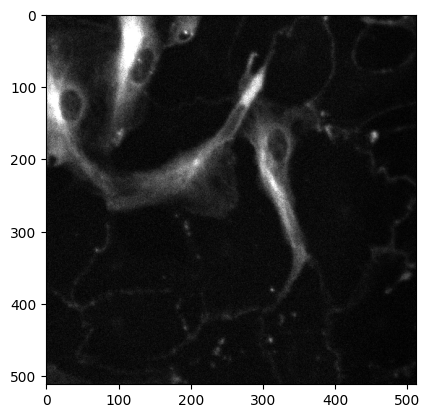

In [21]:
img= imageio.imread(path_to_crops+'/T=200_patch='+str(11)+'.tiff')
vmin, vmax = np.percentile(img, q=(0.5, 99.5))
img_corrected = ski.exposure.rescale_intensity(img, in_range=(vmin, vmax),out_range='uint8') # adjust contrast for visualization
plt.imshow(img_corrected,cmap='gray')

## Load brightfield MAE data

Masked autoencoder dataset info:
- columns 0-255 are the latent features of the contrastive model
- location gives a unique id for each 512x512 patch of the image (stitched FOVs) that is consistent across time (54 locations)
- time is the index into the movie (0 to 576, units 5 minutes)

Original endothelial cell dataset info (from `cellsmap/cellsmap/data_config.yaml`):
- flow rate of 20 dyn/cm^2 from 0 to 24 hours
- flow rate of 6 dyn/cm^2 from 24 to 48 hours
- time interval between images (data points) is 5 minutes

Data loaded and preprocessed in `utils/mae_feats_init.py`.

In [7]:
exp_var = np.load('data/bf_ExpVar.npy')
pcs = np.load('data/bf_PCs.npy')

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Number of modes to explain 95% of variance:  20


In [8]:
X_t = np.load('data/bf_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array

X_t_high = np.load('data/bf_95pctVarPCs_highFlow.npy')
X_t_low = np.load('data/bf_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

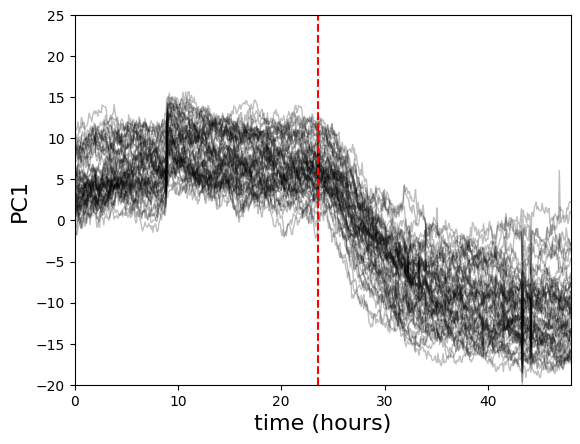

In [9]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-20,25])
plt.vlines(5*t_change/60,-20,25,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

In [26]:
import matplotlib as mpl

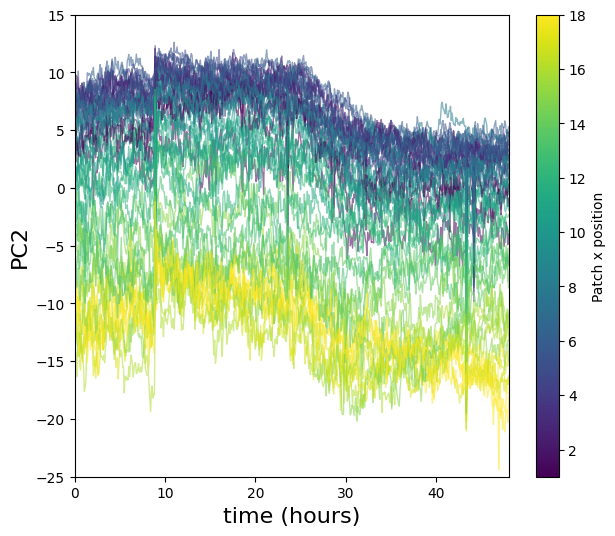

In [31]:
# plot 2nd PCA mode vs time for each location at high flow
# color by x patch postition TO DO
fig = plt.figure(figsize=(7,6))
colors = plt.cm.viridis(np.linspace(0,1,18))
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,1],color=colors[i%18],alpha=0.55,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-25,15])
#plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC2", fontsize=16)
ax = plt.gca()
mynorm = mpl.colors.Normalize(vmin=1, vmax=18)
fig.colorbar(plt.cm.ScalarMappable(norm=mynorm,cmap='viridis'),label='Patch x position',ax=ax)

### Find trajectories that have different PC2 dynamics

In [12]:
hightraj = np.where(X_t[:,0,1] > 7)[0]
hightraj

array([ 4,  5,  8, 19, 20, 21, 22, 23, 37, 39, 40, 41, 43])

In [13]:
lowtraj = np.where(X_t[:,0,1] < -10)[0]
lowtraj

array([15, 33, 34, 35, 50, 51, 52])

In [14]:
hightraj_idx = hightraj[2]
lowtraj_idx = lowtraj[0]
print(hightraj_idx, lowtraj_idx)

8 15


In [15]:
time_pt = 0

Text(0, 0.5, 'PC2')

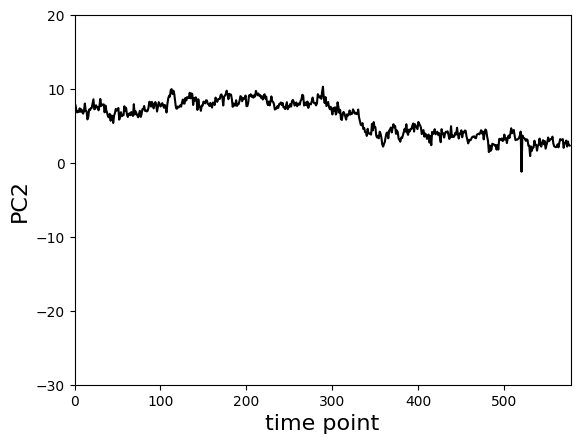

In [154]:
# plot 2nd PCA mode vs time for each location at high flow
for i in [hightraj_idx]:
    plt.plot(np.arange(num_t),X_t[i,:,1],'k-',alpha=1.0,linewidth=1.5)

plt.xlim([0,num_t])
plt.ylim([-30,20])
#plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time point", fontsize=16)
plt.ylabel("PC2", fontsize=16)

Text(0, 0.5, 'PC2')

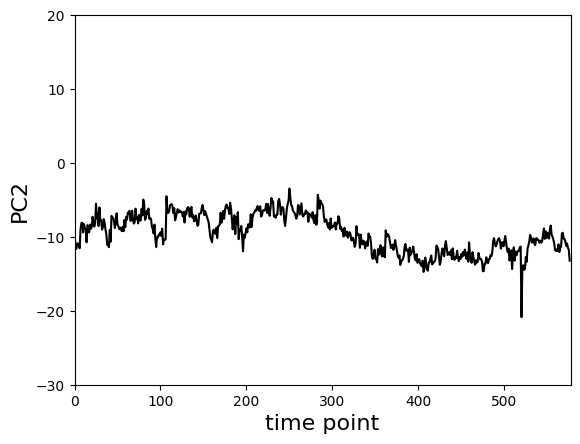

In [155]:
# plot 2nd PCA mode vs time for each location at high flow
for i in [lowtraj_idx]:
    plt.plot(np.arange(num_t),X_t[i,:,1],'k-',alpha=1.0,linewidth=1.5)

plt.xlim([0,num_t])
plt.ylim([-30,20])
#plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time point", fontsize=16)
plt.ylabel("PC2", fontsize=16)

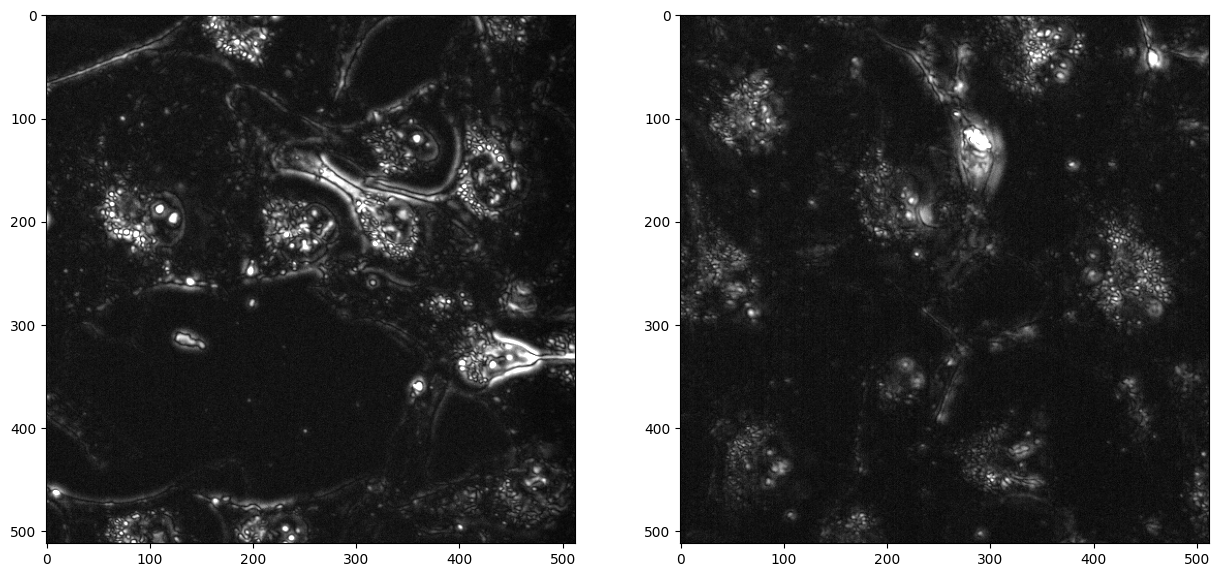

In [158]:
tf = GridSplit(grid=(3, 18), size=(512,512))

time_pt = 20

ome_tif = BioImage(path_to_imgs+'/20240305_T01_001_TP'+str(time_pt).zfill(5)+'.ome.tif')
im = ome_tif.get_image_dask_data('CYX', T=0, C=3).compute()
bf_patches = tf(im)

fig, ax = plt.subplots(1,2,figsize=(15,10))
img_high= bf_patches[hightraj_idx][0]
ax[0].imshow(img_high,cmap='gray',vmax=2000)
img_low= bf_patches[lowtraj_idx][0]
ax[1].imshow(img_low,cmap='gray',vmax=2000)

In [32]:
tf = GridSplit(grid=(3, 18), size=(512,512))

mean_intensity_high = np.zeros(num_t)
mean_intensity_low = np.zeros(num_t)

for time_pt in range(num_t):
    ome_tif = BioImage(path_to_imgs+'/20240305_T01_001_TP'+str(time_pt).zfill(5)+'.ome.tif')
    im = ome_tif.get_image_dask_data('CYX', T=0, C=3).compute()
    bf_patches = tf(im)

    mean_intensity_high[time_pt] = np.mean(bf_patches[hightraj_idx][0])
    mean_intensity_low[time_pt ]= np.mean(bf_patches[lowtraj_idx][0])


In [128]:
plt.plot(np.arange(num_t),mean_intensity_high,'k-',alpha=1.0,linewidth=1.5)
plt.plot(np.arange(num_t),mean_intensity_low,'r-',alpha=1.0,linewidth=1.5)
plt.xlim([0,num_t])
plt.legend(['Crop '+str(hightraj_idx),'Crop '+str(lowtraj_idx)])

407.4589960869371 239.4700008525874
